# A CNN Classifier For Deteting Disease Type

In [2]:
import os
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

from tensorflow.keras.preprocessing.image import load_img, img_to_array
from Scripts.data_augment import get_train_datagen, get_val_test_datagen
from Scripts.class_weighting import calculate_class_weights

In [12]:
train_dir = "split_dataset/train"
val_dir = "split_dataset/val"
test_dir = "split_dataset/test"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

In [13]:
train_datagen = get_train_datagen()
val_test_datagen = get_val_test_datagen()

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

val_generator = val_test_datagen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_generator = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 3149 images belonging to 3 classes.
Found 675 images belonging to 3 classes.
Found 676 images belonging to 3 classes.


In [14]:
class_names, class_weights = calculate_class_weights(train_dir)

print("Class names:", class_names)
print("Class weights:", class_weights)

Class names: ['Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_healthy']
Class weights: {0: np.float64(1.4995238095238095), 1: np.float64(0.7856786427145709), 2: np.float64(0.9430967355495657)}


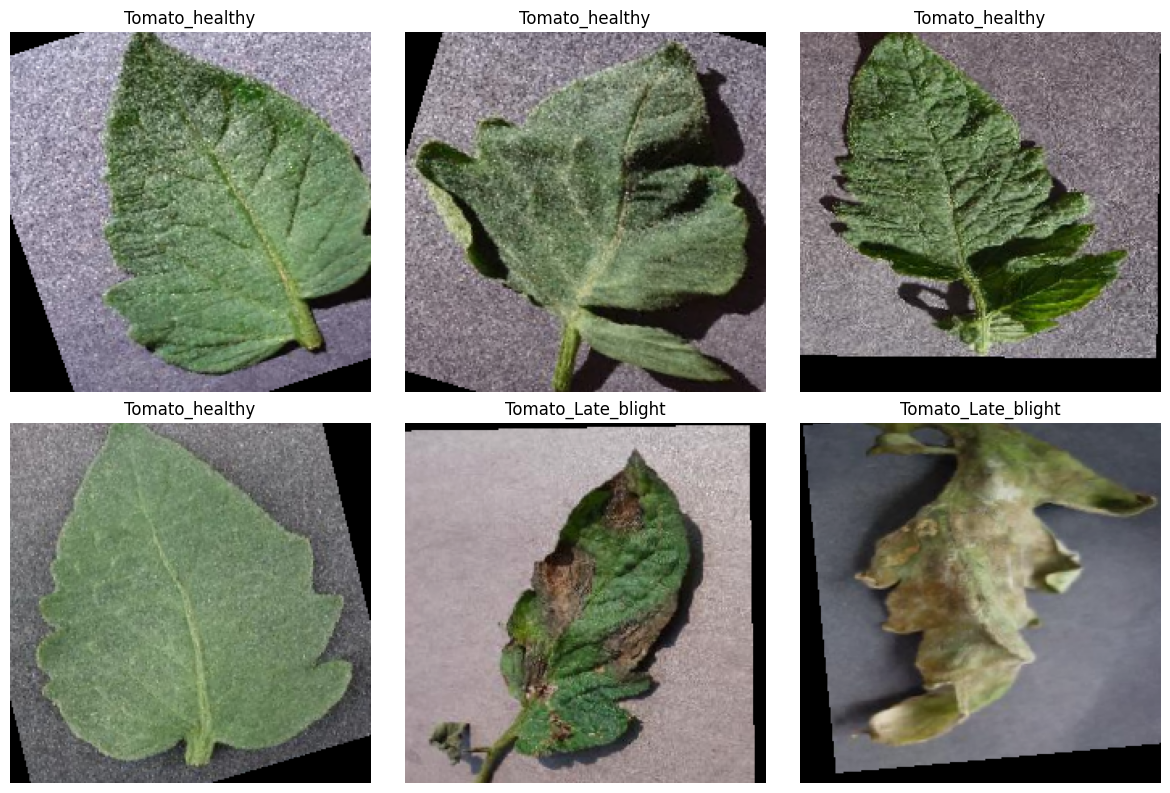

In [15]:
index_to_class = {v: k for k, v in train_generator.class_indices.items()}

sample_batch, sample_labels = next(train_generator)

plt.figure(figsize=(12, 8))
for i in range(6):
    plt.subplot(2, 3, i + 1)
    plt.imshow(sample_batch[i])
    label_index = np.argmax(sample_labels[i])
    plt.title(index_to_class[label_index])
    plt.axis("off")
plt.tight_layout()
plt.show()

## Building an Custom CNN Model

### Build The Sequential Model

In [16]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization

model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)),
    MaxPooling2D(2, 2),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    BatchNormalization(),
    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(3, activation='softmax')
])

model.summary()

c:\Users\Taruni\Desktop\My Projects\quantitative-botanical-reasoning\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 26, 26, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,859 (42.61 MB)

 Trainable params: 11,169,603 (42.61 MB)

 Non-trainable params: 256 (1.00 KB)

In [17]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [18]:
import os
import datetime
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, TensorBoard

os.makedirs("final_model", exist_ok=True)

log_dir = "logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")

early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    restore_best_weights=True,
    verbose=1,
    mode='max'
)

checkpoint = ModelCheckpoint(
    "final_model/best_custom_cnn_model.keras",
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

tensorboard_callback = TensorBoard(
    log_dir=log_dir,
    histogram_freq=1
)

In [19]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    class_weight=class_weights,
    callbacks=[early_stop, checkpoint, tensorboard_callback]
)

Epoch 1/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6670 - loss: 1.6589
Epoch 1: val_accuracy improved from None to 0.46815, saving model to final_model/best_custom_cnn_model.keras

Epoch 1: finished saving model to final_model/best_custom_cnn_model.keras
99/99 ━━━━━━━━━━━━━━━━━━━━ 110s 1s/step - accuracy: 0.7431 - loss: 0.8833 - val_accuracy: 0.4681 - val_loss: 1.5422
Epoch 2/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8296 - loss: 0.4090
Epoch 2: val_accuracy improved from 0.46815 to 0.48444, saving model to final_model/best_custom_cnn_model.keras

Epoch 2: finished saving model to final_model/best_custom_cnn_model.keras
99/99 ━━━━━━━━━━━━━━━━━━━━ 111s 1s/step - accuracy: 0.8361 - loss: 0.3877 - val_accuracy: 0.4844 - val_loss: 0.9370
Epoch 3/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8376 - loss: 0.3587
Epoch 3: val_accuracy improved from 0.48444 to 0.60148, saving model to final_model/best_custom_cnn_model.keras

Epoch 3: finished saving model to f

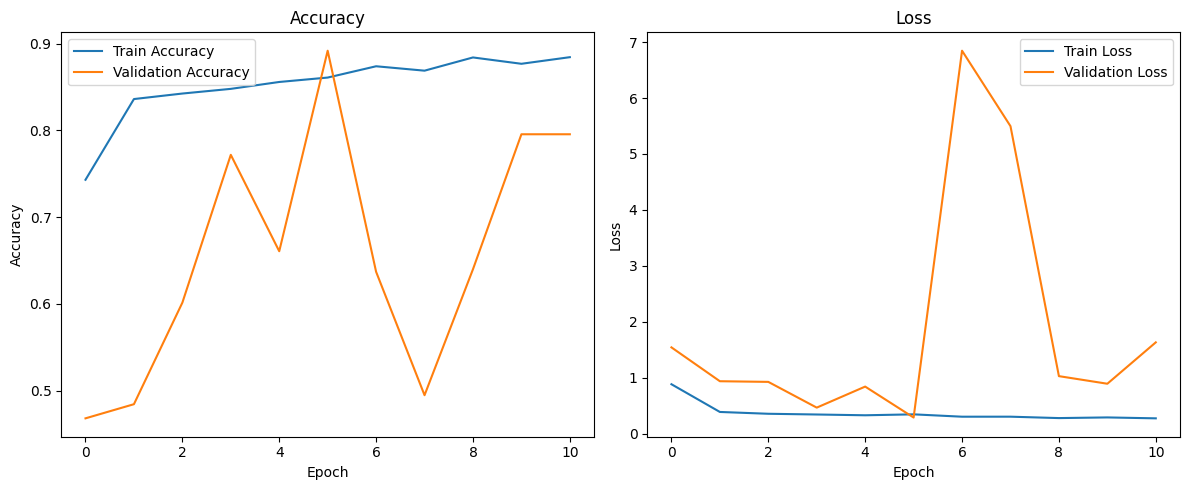

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [21]:
test_loss_cnn, test_acc_cnn = model.evaluate(test_generator)
print("Custom CNN Test Loss:", test_loss_cnn)
print("Custom CNN Test Accuracy:", test_acc_cnn)

22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 160ms/step - accuracy: 0.8935 - loss: 0.2477
Custom CNN Test Loss: 0.24770675599575043
Custom CNN Test Accuracy: 0.8934911489486694


In [22]:
import json, os
os.makedirs("final_model", exist_ok=True)

with open("final_model/history_custom_cnn.json", "w") as f:
    json.dump(history.history, f)

## EfficientNet

In [23]:
import tensorflow as tf

from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, BatchNormalization, Input, Lambda
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

In [24]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

transfer_train_datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.05,
    height_shift_range=0.05,
    zoom_range=0.10,
    horizontal_flip=True
)

transfer_val_test_datagen = ImageDataGenerator()

train_generator_transfer = transfer_train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

val_generator_transfer = transfer_val_test_datagen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_generator_transfer = transfer_val_test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 3149 images belonging to 3 classes.
Found 675 images belonging to 3 classes.
Found 676 images belonging to 3 classes.


In [25]:
input_tensor = Input(shape=(224, 224, 3))

x = Lambda(preprocess_input)(input_tensor)

base_model = EfficientNetB0(
    include_top=False,
    weights='imagenet',
    input_tensor=x
)

base_model.trainable = False

y = base_model.output
y = GlobalAveragePooling2D()(y)
y = BatchNormalization()(y)
y = Dense(128, activation='relu')(y)
y = Dropout(0.3)(y)
output = Dense(3, activation='softmax')(y)

transfer_model = Model(inputs=input_tensor, outputs=output)

transfer_model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 224, 224,  │          0 │ input_layer_2[0]… │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ lambda[0][0]      │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati

 Total params: 4,219,046 (16.09 MB)

 Trainable params: 166,915 (652.01 KB)

 Non-trainable params: 4,052,131 (15.46 MB)

In [26]:
transfer_model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [27]:
os.makedirs("final_model", exist_ok=True)

log_dir_transfer = "logs/fit_transfer/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")

early_stop_transfer = EarlyStopping(
    monitor='val_accuracy',
    patience=3,
    restore_best_weights=True,
    verbose=1,
    mode='max'
)

checkpoint_transfer = ModelCheckpoint(
    "final_model/best_efficientnet_model.keras",
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

tensorboard_transfer = TensorBoard(
    log_dir=log_dir_transfer,
    histogram_freq=1
)

In [28]:
history_transfer = transfer_model.fit(
    train_generator_transfer,
    validation_data=val_generator_transfer,
    epochs=10,
    class_weight=class_weights,
    callbacks=[early_stop_transfer, checkpoint_transfer, tensorboard_transfer]
)

Epoch 1/10
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 850ms/step - accuracy: 0.6409 - loss: 0.9475
Epoch 1: val_accuracy improved from None to 0.87111, saving model to final_model/best_efficientnet_model.keras

Epoch 1: finished saving model to final_model/best_efficientnet_model.keras
99/99 ━━━━━━━━━━━━━━━━━━━━ 116s 1s/step - accuracy: 0.7291 - loss: 0.7029 - val_accuracy: 0.8711 - val_loss: 0.4969
Epoch 2/10
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 853ms/step - accuracy: 0.8435 - loss: 0.4051
Epoch 2: val_accuracy improved from 0.87111 to 0.92741, saving model to final_model/best_efficientnet_model.keras

Epoch 2: finished saving model to final_model/best_efficientnet_model.keras
99/99 ━━━━━━━━━━━━━━━━━━━━ 103s 1s/step - accuracy: 0.8603 - loss: 0.3651 - val_accuracy: 0.9274 - val_loss: 0.2886
Epoch 3/10
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 857ms/step - accuracy: 0.9029 - loss: 0.2782
Epoch 3: val_accuracy improved from 0.92741 to 0.94370, saving model to final_model/best_efficientnet_model.keras

Epoch 3: finishe

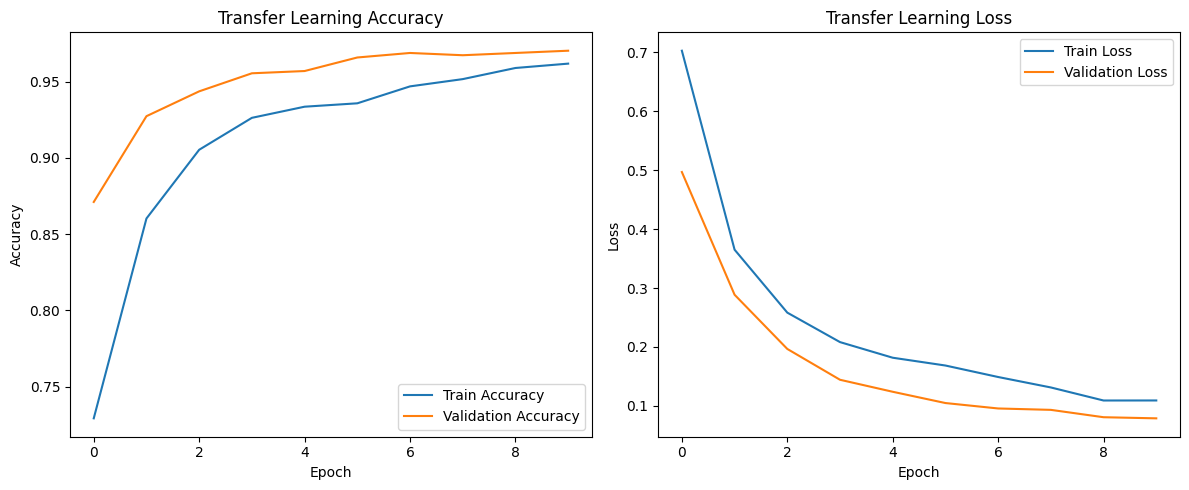

In [29]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_transfer.history['accuracy'], label='Train Accuracy')
plt.plot(history_transfer.history['val_accuracy'], label='Validation Accuracy')
plt.title('Transfer Learning Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_transfer.history['loss'], label='Train Loss')
plt.plot(history_transfer.history['val_loss'], label='Validation Loss')
plt.title('Transfer Learning Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [30]:
test_loss_transfer, test_acc_transfer = transfer_model.evaluate(test_generator_transfer)
print("EfficientNet Test Loss:", test_loss_transfer)
print("EfficientNet Test Accuracy:", test_acc_transfer)

22/22 ━━━━━━━━━━━━━━━━━━━━ 16s 696ms/step - accuracy: 0.9734 - loss: 0.0888
EfficientNet Test Loss: 0.08881263434886932
EfficientNet Test Accuracy: 0.973372757434845


In [31]:
with open("final_model/history_efficientnet.json", "w") as f:
    json.dump(history_transfer.history, f)

## MobileNET

In [32]:
import tensorflow as tf

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess

In [33]:
mobilenet_train_datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.05,
    height_shift_range=0.05,
    zoom_range=0.10,
    horizontal_flip=True
)

mobilenet_val_test_datagen = ImageDataGenerator()

train_generator_mobilenet = mobilenet_train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

val_generator_mobilenet = mobilenet_val_test_datagen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_generator_mobilenet = mobilenet_val_test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 3149 images belonging to 3 classes.
Found 675 images belonging to 3 classes.
Found 676 images belonging to 3 classes.


In [34]:
input_tensor = Input(shape=(224, 224, 3))

x = Lambda(mobilenet_preprocess)(input_tensor)

base_model_mobilenet = MobileNetV2(
    include_top=False,
    weights='imagenet',
    input_tensor=x
)

base_model_mobilenet.trainable = False

y = base_model_mobilenet.output
y = GlobalAveragePooling2D()(y)
y = BatchNormalization()(y)
y = Dense(128, activation='relu')(y)
y = Dropout(0.3)(y)
output = Dense(3, activation='softmax')(y)

mobilenet_model = Model(inputs=input_tensor, outputs=output)

mobilenet_model.summary()

C:\Users\Taruni\AppData\Local\Temp\ipykernel_8108\3370643047.py:5: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model_mobilenet = MobileNetV2(


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_1 (Lambda)   │ (None, 224, 224,  │          0 │ input_layer_3[0]… │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ lambda_1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis

 Total params: 2,427,459 (9.26 MB)

 Trainable params: 166,915 (652.01 KB)

 Non-trainable params: 2,260,544 (8.62 MB)

In [35]:
mobilenet_model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [36]:
os.makedirs("final_model", exist_ok=True)

log_dir_mobilenet = "logs/fit_mobilenet/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")

early_stop_mobilenet = EarlyStopping(
    monitor='val_accuracy',
    patience=3,
    restore_best_weights=True,
    verbose=1,
    mode='max'
)

checkpoint_mobilenet = ModelCheckpoint(
    "final_model/best_mobilenet_model.keras",
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

tensorboard_mobilenet = TensorBoard(
    log_dir=log_dir_mobilenet,
    histogram_freq=1
)

In [37]:
history_mobilenet = mobilenet_model.fit(
    train_generator_mobilenet,
    validation_data=val_generator_mobilenet,
    epochs=10,
    class_weight=class_weights,
    callbacks=[early_stop_mobilenet, checkpoint_mobilenet, tensorboard_mobilenet]
)

Epoch 1/10
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 701ms/step - accuracy: 0.5416 - loss: 1.4045
Epoch 1: val_accuracy improved from None to 0.87407, saving model to final_model/best_mobilenet_model.keras

Epoch 1: finished saving model to final_model/best_mobilenet_model.keras
99/99 ━━━━━━━━━━━━━━━━━━━━ 91s 868ms/step - accuracy: 0.6729 - loss: 0.9297 - val_accuracy: 0.8741 - val_loss: 0.4034
Epoch 2/10
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 707ms/step - accuracy: 0.8440 - loss: 0.4308
Epoch 2: val_accuracy improved from 0.87407 to 0.90519, saving model to final_model/best_mobilenet_model.keras

Epoch 2: finished saving model to final_model/best_mobilenet_model.keras
99/99 ━━━━━━━━━━━━━━━━━━━━ 84s 852ms/step - accuracy: 0.8533 - loss: 0.4003 - val_accuracy: 0.9052 - val_loss: 0.2748
Epoch 3/10
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 702ms/step - accuracy: 0.8838 - loss: 0.3174
Epoch 3: val_accuracy improved from 0.90519 to 0.91259, saving model to final_model/best_mobilenet_model.keras

Epoch 3: finished saving mo

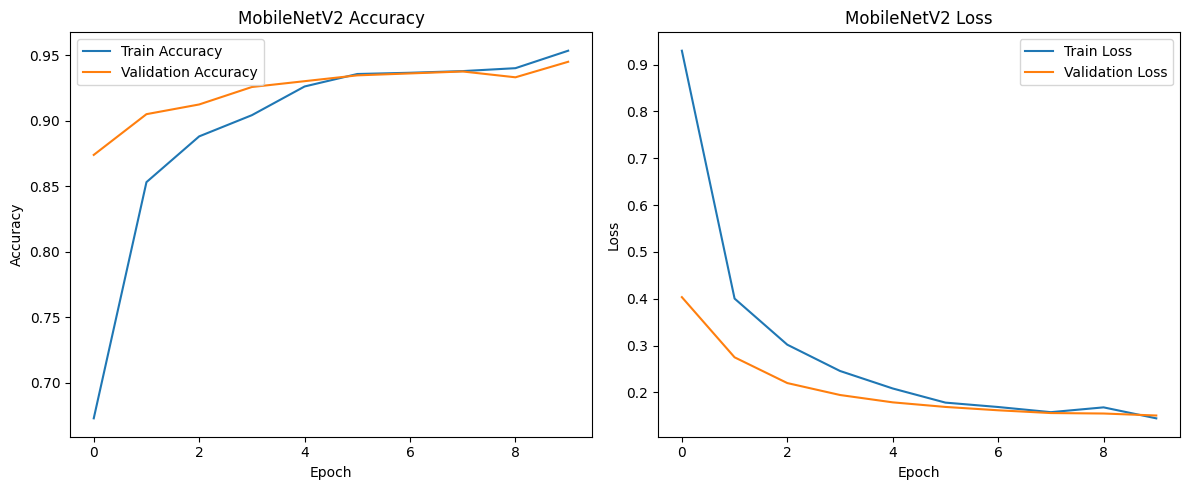

In [38]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_mobilenet.history['accuracy'], label='Train Accuracy')
plt.plot(history_mobilenet.history['val_accuracy'], label='Validation Accuracy')
plt.title('MobileNetV2 Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_mobilenet.history['loss'], label='Train Loss')
plt.plot(history_mobilenet.history['val_loss'], label='Validation Loss')
plt.title('MobileNetV2 Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [39]:
test_loss_mobilenet, test_acc_mobilenet = mobilenet_model.evaluate(test_generator_mobilenet)
print("MobileNetV2 Test Loss:", test_loss_mobilenet)
print("MobileNetV2 Test Accuracy:", test_acc_mobilenet)

22/22 ━━━━━━━━━━━━━━━━━━━━ 12s 537ms/step - accuracy: 0.9408 - loss: 0.1540
MobileNetV2 Test Loss: 0.15400633215904236
MobileNetV2 Test Accuracy: 0.9408283829689026


In [40]:
with open("final_model/history_mobilenet.json", "w") as f:
    json.dump(history_mobilenet.history, f)

## Training Summary and Initial Model Comparison

In [41]:
import pandas as pd

training_summary = pd.DataFrame({
    "Model": ["Custom CNN", "EfficientNetB0", "MobileNetV2"],
    "Final Train Accuracy": [
        history.history['accuracy'][-1],
        history_transfer.history['accuracy'][-1],
        history_mobilenet.history['accuracy'][-1]
    ],
    "Best Val Accuracy": [
        max(history.history['val_accuracy']),
        max(history_transfer.history['val_accuracy']),
        max(history_mobilenet.history['val_accuracy'])
    ],
    "Test Accuracy": [
        test_acc_cnn,
        test_acc_transfer,
        test_acc_mobilenet
    ],
    "Test Loss": [
        test_loss_cnn,
        test_loss_transfer,
        test_loss_mobilenet
    ]
})

training_summary

,Model,Final Train Accuracy,Best Val Accuracy,Test Accuracy,Test Loss
0,Custom CNN,0.884408,0.891852,0.893491,0.247707
1,EfficientNetB0,0.961893,0.970370,0.973373,0.088813
2,MobileNetV2,0.953636,0.945185,0.940828,0.154006


In [42]:
training_summary.to_csv("final_model/training_summary.csv", index=False)

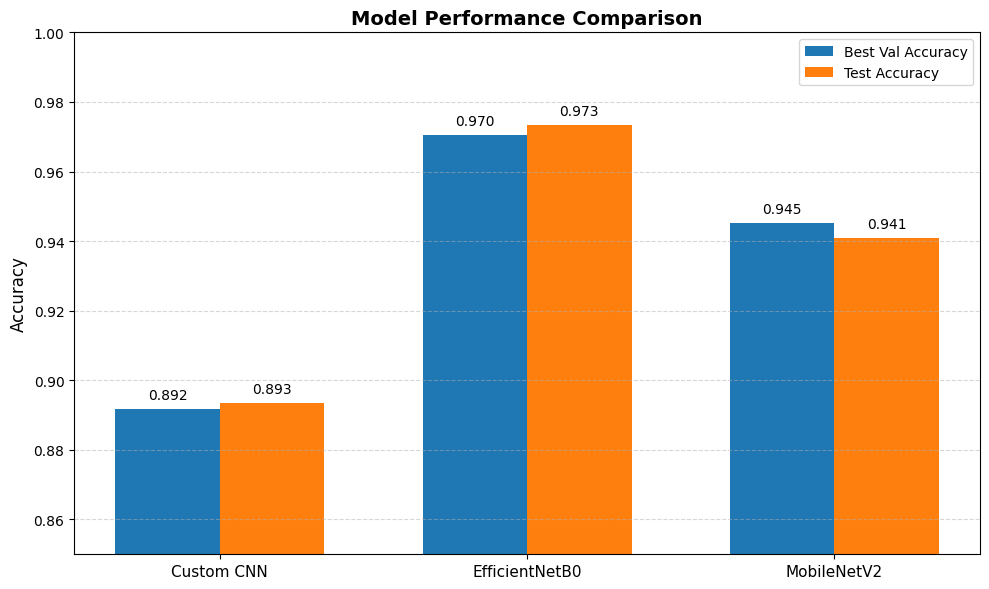

In [ ]:
import numpy as np

models = training_summary["Model"]
best_val_acc = training_summary["Best Val Accuracy"]
test_acc = training_summary["Test Accuracy"]

x = np.arange(len(models))
width = 0.34

plt.figure(figsize=(10, 6))

bars1 = plt.bar(x - width/2, best_val_acc, width, label="Best Val Accuracy")
bars2 = plt.bar(x + width/2, test_acc, width, label="Test Accuracy")

plt.xticks(x, models, fontsize=11)
plt.yticks(fontsize=10)
plt.ylim(0.85, 1.00)   # tighter range to show differences clearly
plt.ylabel("Accuracy", fontsize=12)
plt.title("Model Performance Comparison", fontsize=14, fontweight="bold")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            height + 0.002,
            f"{height:.3f}",
            ha='center',
            va='bottom',
            fontsize=10
        )

plt.tight_layout()
plt.show()